# Thick-Walled Cylinder — pyGmshViewer Integration (v2)

This notebook extends the `example_plate_pyGmsh` workflow by adding:

1. **Results container** — wrap mesh + FEM fields in a `Results` object via `Results.from_fem()`
2. **pyGmshViewer** launch — standalone Qt/VTK viewer with contours, deformed shapes, and probes
3. **Programmatic probing** — sample field values at points, along lines, and on cut planes

## v2 Changes

Updated to use the current pyGmsh API:

- **`renumber_mesh()` + `get_fem_data()`** — single FEMData object replaces the old `get_numbered_mesh()`
- **FEMData convenience methods** — `.nodes()`, `.elements()`, `.node_index()`,
  `.get_node_coords()` replace manual maps and index lookups
- **`fem.physical`** — boundary/load queries live on the FEMData snapshot, no separate `g.physical` calls
- **`Results.from_fem()`** — high-level results container replaces manual `VTKExport`
- **`results.viewer()`** — launch the viewer directly from the Results object

In [1]:
from apeGmsh import apeGmsh, Results
import numpy as np
import openseespy.opensees as ops

## 1 — Geometry & Mesh

Same Lamé problem as `example_plate_pyGmsh.ipynb`. After meshing, we call
`renumber_mesh(method='rcm')` to get contiguous solver-ready IDs, then
`get_fem_data()` to snapshot everything into one `FEMData` object.

In [2]:
# ============================================================
# Parameters
# ============================================================
inner_radius = 100.0    # [mm]
outer_radius = 200.0    # [mm]
lc           = 10.0     # [mm] mesh size
E   = 210.0e3           # [MPa]
nu  = 0.3
p   = 100.0             # [MPa] internal pressure
thk = 1.0               # [mm]

# ============================================================
# pyGmsh: Geometry + Mesh
# ============================================================
g = apeGmsh(model_name="Plate2D", verbose=False)
g.begin()

pc = g.model.geometry.add_point(0, 0, 0, lc=lc)
p1 = g.model.geometry.add_point(inner_radius, 0, 0, lc=lc)
p2 = g.model.geometry.add_point(outer_radius, 0, 0, lc=lc)
p3 = g.model.geometry.add_point(0, outer_radius, 0, lc=lc)
p4 = g.model.geometry.add_point(0, inner_radius, 0, lc=lc)

l1 = g.model.geometry.add_line(p1, p2)
l2 = g.model.geometry.add_arc(p2, pc, p3)
l3 = g.model.geometry.add_line(p3, p4)
l4 = g.model.geometry.add_arc(p4, pc, p1)

loop = g.model.geometry.add_curve_loop([l1, l2, l3, l4])
surf = g.model.geometry.add_plane_surface(loop)

pg_symY = g.physical.add(1, [l1], name="Sym_Y")
pg_symX = g.physical.add(1, [l3], name="Sym_X")
pg_pres = g.physical.add(1, [l4], name="Pressure")
pg_plat = g.physical.add(2, [surf], name="Plate")

g.mesh.generation.set_order(1)
g.mesh.generation.generate(2)

# Renumber to contiguous solver-ready IDs (RCM for bandwidth reduction)
g.mesh.partitioning.renumber(method='rcm')

# Extract the single FEMData object — this is our sole data source
fem = g.mesh.queries.get_fem_data(dim=2)
print(fem.info)
fem.physical.summary()

[FEMData] WARNING: 1 orphan node(s) removed (not connected to any element). Tags: [331]
MeshInfo(n_nodes=330, n_elems=590, bandwidth=314)


name  n_nodes  n_elems
dim pg_tag                            
1   1          Sym_Y       11       10
    2          Sym_X       11       10
    3       Pressure       17       16
2   4          Plate      330      590

In [3]:
# ============================================================
# OpenSees: Build model, apply loads, solve
# ============================================================
# After renumber_mesh(), fem.nodes.ids and fem.elements.ids ARE
# the solver IDs — no Gmsh↔solver translation needed.
# ============================================================

ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 2)

# --- Nodes (using FEMData iterator) ---
for nid, coords in fem.nodes():
    ops.node(nid, *coords)

# --- Material ---
ops.nDMaterial("ElasticIsotropic", 1, E, nu)

# --- Elements (using FEMData iterator) ---
for eid, conn in fem.elements():
    ops.element("tri31", eid, *conn, thk, "PlaneStrain", 1)

# --- Boundary conditions (from fem.physical) ---
for nid in fem.physical.get_nodes(1, pg_symY)['tags']:
    ops.fix(nid, 0, 1)   # Sym_Y: fix uy, free ux

for nid in fem.physical.get_nodes(1, pg_symX)['tags']:
    ops.fix(nid, 1, 0)   # Sym_X: fix ux, free uy

# --- Consistent pressure loads on inner arc ---
# Edge elements from fem.physical — already in solver IDs
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

inner = (lambda _ids_conn: {'ids': _ids_conn[0], 'connectivity': _ids_conn[1]})(fem.elements.resolve(pg=pg_pres, dim=1))
inner_edges = inner['connectivity']   # (nEdge, 2)

nodal_forces = {}
for edge in inner_edges:
    n1, n2 = int(edge[0]), int(edge[1])

    # Coordinates via FEMData lookup
    x1, y1, _ = fem.get_node_coords(n1)
    x2, y2, _ = fem.get_node_coords(n2)

    Le = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    r1 = np.sqrt(x1**2 + y1**2)
    r2 = np.sqrt(x2**2 + y2**2)

    # Traction: t = p * (x/r, y/r)
    tx1, ty1 = p * x1/r1, p * y1/r1
    tx2, ty2 = p * x2/r2, p * y2/r2

    # Consistent nodal forces: F = integral(N^T * t dGamma)
    Fx1 = (Le/6) * (2*tx1 + tx2);  Fy1 = (Le/6) * (2*ty1 + ty2)
    Fx2 = (Le/6) * (tx1 + 2*tx2);  Fy2 = (Le/6) * (ty1 + 2*ty2)

    nodal_forces.setdefault(n1, [0., 0.])
    nodal_forces.setdefault(n2, [0., 0.])
    nodal_forces[n1][0] += Fx1;  nodal_forces[n1][1] += Fy1
    nodal_forces[n2][0] += Fx2;  nodal_forces[n2][1] += Fy2

for nid, (fx, fy) in nodal_forces.items():
    ops.load(nid, fx, fy)

# --- Solve ---
ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.test("NormDispIncr", 1e-8, 10)
ops.algorithm("Newton")
ops.integrator("LoadControl", 1.0)
ops.analysis("Static")
ok = ops.analyze(1)
print("CONVERGED" if ok == 0 else "FAILED")

CONVERGED


Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [ ]:
from apeGmsh import workdir
OUT = workdir()
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=2, ndf=2)

results_capture = OUT / "capture.h5"
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=2, ndf=2) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 4 ---
    # ============================================================
    # OpenSees: Build model, apply loads, solve
    # ============================================================
    # After renumber_mesh(), fem.nodes.ids and fem.elements.ids ARE
    # the solver IDs — no Gmsh↔solver translation needed.
    # ============================================================

    ops.wipe()
    ops.model("basic", "-ndm", 2, "-ndf", 2)

    # --- Nodes (using FEMData iterator) ---
    for nid, coords in fem.nodes():
        ops.node(nid, *coords)

    # --- Material ---
    ops.nDMaterial("ElasticIsotropic", 1, E, nu)

    # --- Elements (using FEMData iterator) ---
    for eid, conn in fem.elements():
        ops.element("tri31", eid, *conn, thk, "PlaneStrain", 1)

    # --- Boundary conditions (from fem.physical) ---
    for nid in fem.physical.get_nodes(1, pg_symY)['tags']:
        ops.fix(nid, 0, 1)   # Sym_Y: fix uy, free ux

    for nid in fem.physical.get_nodes(1, pg_symX)['tags']:
        ops.fix(nid, 1, 0)   # Sym_X: fix ux, free uy

    # --- Consistent pressure loads on inner arc ---
    # Edge elements from fem.physical — already in solver IDs
    ops.timeSeries("Linear", 1)
    ops.pattern("Plain", 1, 1)

    inner = (lambda _ids_conn: {'ids': _ids_conn[0], 'connectivity': _ids_conn[1]})(fem.elements.resolve(pg=pg_pres, dim=1))
    inner_edges = inner['connectivity']   # (nEdge, 2)

    nodal_forces = {}
    for edge in inner_edges:
        n1, n2 = int(edge[0]), int(edge[1])

        # Coordinates via FEMData lookup
        x1, y1, _ = fem.get_node_coords(n1)
        x2, y2, _ = fem.get_node_coords(n2)

        Le = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        r1 = np.sqrt(x1**2 + y1**2)
        r2 = np.sqrt(x2**2 + y2**2)

        # Traction: t = p * (x/r, y/r)
        tx1, ty1 = p * x1/r1, p * y1/r1
        tx2, ty2 = p * x2/r2, p * y2/r2

        # Consistent nodal forces: F = integral(N^T * t dGamma)
        Fx1 = (Le/6) * (2*tx1 + tx2);  Fy1 = (Le/6) * (2*ty1 + ty2)
        Fx2 = (Le/6) * (tx1 + 2*tx2);  Fy2 = (Le/6) * (ty1 + 2*ty2)

        nodal_forces.setdefault(n1, [0., 0.])
        nodal_forces.setdefault(n2, [0., 0.])
        nodal_forces[n1][0] += Fx1;  nodal_forces[n1][1] += Fy1
        nodal_forces[n2][0] += Fx2;  nodal_forces[n2][1] += Fy2

    for nid, (fx, fy) in nodal_forces.items():
        ops.load(nid, fx, fy)

    # --- Solve ---
    ops.constraints("Transformation")
    ops.numberer("RCM")
    ops.system("BandGeneral")
    ops.test("NormDispIncr", 1e-8, 10)
    ops.algorithm("Newton")
    ops.integrator("LoadControl", 1.0)
    ops.analysis("Static")
    ok = ops.analyze(1)
    cap.step(t=ops.getTime())
    print("CONVERGED" if ok == 0 else "FAILED")
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


In [ ]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess,
# non-blocking). Set APEGMSH_SKIP_VIEWER=1 to skip in headless / CI.
import os
from apeGmsh.results import Results
results = Results.from_native(results_capture)
if os.environ.get("APEGMSH_SKIP_VIEWER"):
    print("[skip viewer] APEGMSH_SKIP_VIEWER set")
else:
    handle = results.viewer(blocking=False)
    print(f"viewer pid: {handle.pid}  -- close window to exit.")


In [4]:
# ============================================================
# Extract results into numpy arrays
# ============================================================
# After renumber_mesh(), fem IDs = solver IDs.
# No Gmsh↔solver translation — index directly via FEMData.
# ============================================================

nNode = fem.info.n_nodes
nElem = fem.info.n_elems

# -- Displacements --
disp = np.zeros((nNode, 2))
for i, nid in enumerate(fem.nodes.ids):
    disp[i, 0] = ops.nodeDisp(int(nid), 1)
    disp[i, 1] = ops.nodeDisp(int(nid), 2)

# -- Radial displacement --
r_nodes = np.sqrt(fem.nodes.coords[:, 0]**2 + fem.nodes.coords[:, 1]**2)
r_safe  = np.where(r_nodes > 1e-12, r_nodes, 1.0)
ur = (fem.nodes.coords[:, 0]*disp[:, 0] + fem.nodes.coords[:, 1]*disp[:, 1]) / r_safe

# -- Element stresses (CST: one constant stress per element) --
sig_xx = np.zeros(nElem)
sig_yy = np.zeros(nElem)
sig_xy = np.zeros(nElem)

for i, eid in enumerate(fem.elements.ids):
    s = ops.eleResponse(int(eid), "stresses")
    sig_xx[i] = s[0]
    sig_yy[i] = s[1]
    sig_xy[i] = s[2]

# -- Nodal-averaged stress --
conn_idx = np.array([[fem.node_index(n) for n in row] for row in fem.elements.connectivity])
sig_xx_nodal = np.zeros(nNode)
node_count   = np.zeros(nNode)

for e in range(nElem):
    for ln in range(3):
        nidx = conn_idx[e, ln]
        sig_xx_nodal[nidx] += sig_xx[e]
        node_count[nidx]   += 1.0

node_count[node_count == 0] = 1.0
sig_xx_nodal /= node_count

# -- Von Mises --
von_mises_elem = np.sqrt(sig_xx**2 - sig_xx*sig_yy + sig_yy**2 + 3*sig_xy**2)

print(f"u_r  range: [{ur.min():.6f}, {ur.max():.6f}] mm")
print(f"\u03c3_xx range: [{sig_xx.min():.2f}, {sig_xx.max():.2f}] MPa")
print(f"\u03c3_vm range: [{von_mises_elem.min():.2f}, {von_mises_elem.max():.2f}] MPa")

ops.wipe()
print("\nOpenSees wiped — results stored in numpy arrays.")

u_r  range: [0.057372, 0.090446] mm
σ_xx range: [-101.83, 174.50] MPa
σ_vm range: [65.26, 232.92] MPa

OpenSees wiped — results stored in numpy arrays.


## 2 — Build Results Container

`Results.from_fem()` wraps the FEMData mesh geometry together with all
numpy result arrays into a single object.  It handles 0-based connectivity
remapping and VTK cell type detection internally.

The `Results` object provides:

| Method | Purpose |
|--------|---------|
| `results.viewer()` | Launch pyGmshViewer (blocking or non-blocking) |
| `results.to_mesh_data()` | In-memory MeshData for programmatic probing |
| `results.to_vtu(path)` | Export single `.vtu` file |
| `results.to_pvd(base)` | Export time-series (`.pvd` + `.vtu` files) |
| `results.summary()` | Human-readable summary string |

In [5]:
from pathlib import Path

from apeGmsh import workdir
output_dir = workdir()

# Finalize Gmsh (no longer needed — Results takes a FEMData snapshot)
g.end()

# Build Results from FEMData + numpy arrays


Results: 'lame_plate'
  Mesh: 330 nodes, 626 elements (590 primary + 36 extra)
  Point fields: Displacement, Displacement_Y, Radial_Disp, Stress_XX_nodal
  Cell fields:  Stress_XX, Stress_YY, Stress_XY, VonMises
  Physical groups: 4


In [6]:
# Optional: export VTU for ParaView or external tools
vtu_path = results.to_vtu(output_dir / "lame_plate_results.vtu")
print(f"VTU exported: {vtu_path}")

VTU exported: generated\lame_plate_results.vtu


## 3 — Launch pyGmshViewer

The `Results` object has a built-in `.viewer()` method that launches pyGmshViewer
directly — no manual VTU export required:

```python
results.viewer(blocking=False)   # non-blocking (Jupyter — notebook keeps running)
results.viewer(blocking=True)    # blocking (script — waits until window closed)
```

Other ways to launch the viewer:

```python
from apeGmshViewer import show
show("results.vtu", blocking=False)          # from a VTU file
show("results.vtu", "modes.pvd")             # multiple files
```

Or from the command line:
```bash
python -m pyGmshViewer generated/lame_plate_results.vtu
```

### Viewer Controls

| Feature | How |
|---------|-----|
| **Contour plot** | Click any field in the Model Tree |
| **Deformed shape** | Controls panel → check "Show Deformed Shape", set scale |
| **Point probe** | Ctrl+P or Probes panel → Point, then click on mesh |
| **Line probe** | Ctrl+L or Probes panel → Line, then two clicks |
| **Plane slice** | Probes panel → Slice X/Y/Z or Interactive Plane |
| **Camera** | XY, XZ, YZ, Iso toolbar buttons or drag to rotate |
| **Screenshot** | Ctrl+S |

In [7]:
# Launch the viewer directly from Results (non-blocking so the notebook keeps running)
results.viewer(blocking=False)
print("Viewer launched")

Viewer launched


## 4 — Programmatic Probing with pyGmshViewer

The **ProbeEngine** can be used programmatically (without the GUI) to sample
field values at specific locations. Three probe types:

- **Point probe** — interpolate all fields at a single coordinate
- **Line probe** — sample N evenly-spaced points along a line → numpy arrays
- **Plane probe** — slice the mesh with an arbitrary plane

The probes use VTK interpolation under the hood, so they work at **any**
location — not just at mesh nodes. Results come back as typed dataclasses
(`PointProbeResult`, `LineProbeResult`, `PlaneProbeResult`) with numpy arrays
ready for plotting.

In [8]:
import pyvista as pv
from apeGmshViewer.visualization.probes import ProbeEngine

# Get MeshData directly from Results (no file I/O)
mesh_data = results.to_mesh_data()
print(f"Loaded: {mesh_data.n_points} points, {mesh_data.n_cells} cells")
print(f"Point fields: {mesh_data.point_field_names}")
print(f"Cell fields:  {mesh_data.cell_field_names}")

# Create an offscreen probe engine (no GUI needed)
plotter = pv.Plotter(off_screen=True)
probe = ProbeEngine(plotter)
probe.set_active_mesh(mesh_data.mesh, mesh_data.name)

Loaded: 330 points, 626 cells
Point fields: ['Displacement', 'Displacement_Y', 'Radial_Disp', 'Stress_XX_nodal']
Cell fields:  ['Stress_XX', 'Stress_YY', 'Stress_XY', 'VonMises']


In [9]:
# ============================================================
# Point Probe: sample at the inner wall along the x-axis
# ============================================================
# This is where the analytical solution gives maximum hoop stress.

result = probe.probe_at_point([inner_radius, 0.0, 0.0])
print(result.summary())

Point Probe at (100.0000, 0.0000, 0.0000)
Nearest node: 0 (d = 0.0000e+00)
  Displacement: [0.090249 0.      ]  (|v| = 9.024900e-02)
  Displacement_Y: 0.000000e+00
  Radial_Disp: 9.024900e-02
  Stress_XX_nodal: -8.392853e+01


In [10]:
# ============================================================
# Line Probe: radial profile along x-axis (r = R_i to R_o)
# ============================================================
# ProbeEngine.probe_along_line returns a LineProbeResult with
# arc_length and field_values as numpy arrays.

line_result = probe.probe_along_line(
    point_a=[inner_radius, 0, 0],
    point_b=[outer_radius, 0, 0],
    n_samples=200,
)

r_sampled      = line_result.positions[:, 0]   # x = r along this line
sig_xx_sampled = line_result.field_values["Stress_XX_nodal"]
ur_sampled     = line_result.field_values["Radial_Disp"]

print(f"Line probe: {line_result.n_samples} samples, length = {line_result.total_length:.1f} mm")
print(f"  Stress_XX range: [{sig_xx_sampled.min():.2f}, {sig_xx_sampled.max():.2f}] MPa")

Line probe: 200 samples, length = 100.0 mm
  Stress_XX range: [-83.93, -2.25] MPa


In [11]:
# ============================================================
# Analytical solution (Lamé)
# ============================================================
# Along the x-axis (theta=0):
#   sigma_rr = sigma_xx = A + B/r^2
#   sigma_tt = sigma_yy = A - B/r^2
#   u_r = (1/E) * [(1+nu)*B/r + (1-2*nu)*(1+nu)*A*r]
#
# where A = p*a^2 / (b^2 - a^2),  B = -p*a^2*b^2 / (b^2 - a^2)

a, b = inner_radius, outer_radius
A_lame = p * a**2 / (b**2 - a**2)
B_lame = -p * a**2 * b**2 / (b**2 - a**2)

r_analytical = np.linspace(inner_radius, outer_radius, 500)
sig_rr_exact = A_lame + B_lame / r_analytical**2
sig_tt_exact = A_lame - B_lame / r_analytical**2
ur_exact = (1/E) * ((1+nu)*B_lame/r_analytical + (1-2*nu)*(1+nu)*A_lame*r_analytical)

print(f"Analytical at inner wall: \u03c3_rr = {sig_rr_exact[0]:.2f}, \u03c3_tt = {sig_tt_exact[0]:.2f} MPa")
print(f"Analytical at outer wall: \u03c3_rr = {sig_rr_exact[-1]:.2f}, \u03c3_tt = {sig_tt_exact[-1]:.2f} MPa")

Analytical at inner wall: σ_rr = -100.00, σ_tt = 166.67 MPa
Analytical at outer wall: σ_rr = 0.00, σ_tt = 66.67 MPa


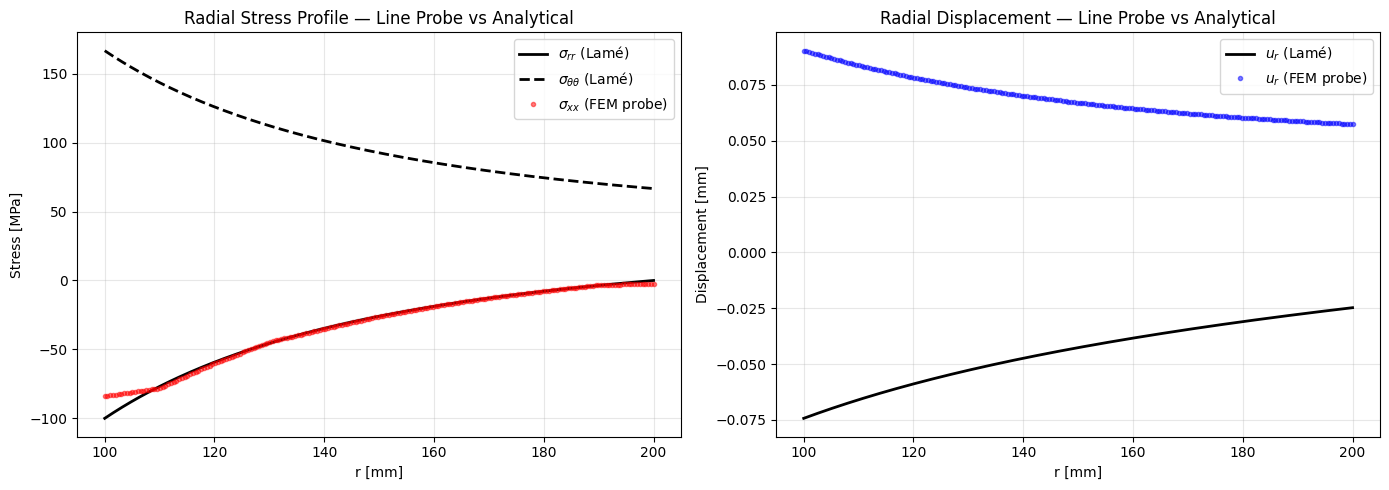


Plot saved: generated\lame_probe_comparison.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Radial stress profile: FEM probe vs analytical
ax = axes[0]
ax.plot(r_analytical, sig_rr_exact, 'k-', lw=2, label=r'$\sigma_{rr}$ (Lamé)')
ax.plot(r_analytical, sig_tt_exact, 'k--', lw=2, label=r'$\sigma_{\theta\theta}$ (Lamé)')
ax.plot(r_sampled, sig_xx_sampled, 'ro', ms=3, alpha=0.5,
        label=r'$\sigma_{xx}$ (FEM probe)')
ax.set_xlabel('r [mm]')
ax.set_ylabel('Stress [MPa]')
ax.set_title('Radial Stress Profile — Line Probe vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Radial displacement: FEM probe vs analytical
ax = axes[1]
ax.plot(r_analytical, ur_exact, 'k-', lw=2, label=r'$u_r$ (Lamé)')
ax.plot(r_sampled, ur_sampled, 'bo', ms=3, alpha=0.5,
        label=r'$u_r$ (FEM probe)')
ax.set_xlabel('r [mm]')
ax.set_ylabel('Displacement [mm]')
ax.set_title('Radial Displacement — Line Probe vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(output_dir / "lame_probe_comparison.png"), dpi=150)
plt.show()
print(f"\nPlot saved: {output_dir / 'lame_probe_comparison.png'}")

## 5 — Plane Probe (Slice)

Cut the mesh with a plane to inspect field values on the cross-section.
Useful for 3D models where you want to see internal stress distributions.

For this 2D problem (z=0 plane), a radial cut line is more natural,
but we demonstrate the API for completeness.

Plane slice: 31 points
Fields on slice: ['Displacement', 'Displacement_Y', 'Radial_Disp', 'Stress_XX_nodal', 'Stress_XX', 'Stress_YY', 'Stress_XY', 'VonMises']


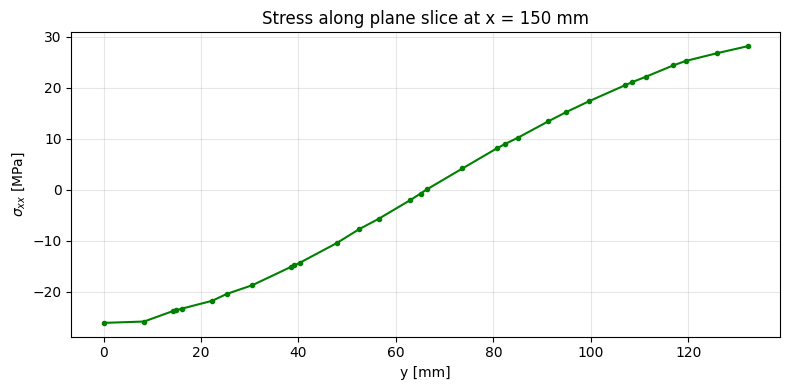

In [13]:
# ============================================================
# Plane Probe: slice at x = 150 mm (normal = x-direction)
# ============================================================
# ProbeEngine.probe_with_plane returns a PlaneProbeResult with
# the sliced geometry and all interpolated fields.

import matplotlib.pyplot as plt

plane_result = probe.probe_with_plane(
    origin=[150.0, 0.0, 0.0],
    normal=[1.0, 0.0, 0.0],     # cut perpendicular to x-axis
)

if plane_result and plane_result.slice_mesh.n_points > 0:
    print(f"Plane slice: {plane_result.slice_mesh.n_points} points")
    print(f"Fields on slice: {plane_result.field_names}")

    # Extract data along the slice for plotting
    slice_y = np.array(plane_result.slice_mesh.points)[:, 1]
    slice_stress = np.array(plane_result.slice_mesh.point_data.get("Stress_XX_nodal", []))

    if len(slice_stress) > 0:
        order = np.argsort(slice_y)
        plt.figure(figsize=(8, 4))
        plt.plot(slice_y[order], slice_stress[order], 'g.-', lw=1.5)
        plt.xlabel('y [mm]')
        plt.ylabel(r'$\sigma_{xx}$ [MPa]')
        plt.title(f'Stress along plane slice at x = {plane_result.origin[0]:.0f} mm')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Slice returned no points (plane may not intersect the mesh).")

## 6 — Offscreen Rendering with ViewportRenderer

The `ViewportRenderer` wraps a PyVista plotter with FEM-specific methods:
`set_scalar_field`, `show_deformed`, `screenshot`. We use an offscreen
plotter so no window pops up — the result is a PNG screenshot displayed
inline in the notebook.

In [14]:
from apeGmshViewer.visualization.renderer import ViewportRenderer
from IPython.display import Image, display

# Create an offscreen renderer
render_plotter = pv.Plotter(off_screen=True, window_size=[900, 500])
renderer = ViewportRenderer(render_plotter)

# Add the mesh and set Von Mises contour
renderer.add_mesh(mesh_data, name="plate")
renderer.set_scalar_field("plate", "VonMises", colormap="Turbo")
renderer.view_xy()

# Save and display
img_path = str(output_dir / 'lame_vonmises.png')
renderer.screenshot(img_path)
display(Image(filename=img_path, width=800))
print(f"Screenshot saved: {img_path}")

ValueError: Invalid colormap 'Turbo'

In [ ]:
# Deformed shape with radial displacement contour
render_plotter2 = pv.Plotter(off_screen=True, window_size=[900, 500])
renderer2 = ViewportRenderer(render_plotter2)

renderer2.add_mesh(mesh_data, name="plate")
renderer2.set_scalar_field("plate", "Radial_Disp", colormap="Coolwarm")
renderer2.show_deformed("plate", displacement_field="Displacement", scale_factor=500.0)
renderer2.view_xy()

img_path = str(output_dir / 'lame_deformed.png')
renderer2.screenshot(img_path)
display(Image(filename=img_path, width=800))
print(f"Deformed shape saved: {img_path}")

## Summary

The full pipeline from geometry to interactive visualization:

```
pyGmsh (geometry + mesh)
    │
    ├── renumber_mesh(method='rcm')   ← mutates Gmsh model
    │
    ├── get_fem_data()  →  FEMData    ← single data source
    │       │
    │       ├── fem.nodes() / fem.elements()  → OpenSees
    │       ├── fem.physical.get_nodes/get_elements()  → BCs & loads
    │       ├── fem.node_index() / fem.get_node_coords()  → lookups
    │       │
    │       └── OpenSees (solve)  →  numpy arrays
    │
    └── Results.from_fem(fem, point_data={...}, cell_data={...})
            │
            ├── results.viewer()         → interactive Qt GUI
            ├── results.to_mesh_data()   → MeshData (in-memory)
            ├── results.to_vtu()         → export .vtu for ParaView
            ├── results.to_pvd()         → export time-series
            ├── results.summary()        → human-readable summary
            │
            └── MeshData
                    │
                    ├── ProbeEngine          → point / line / plane probes
                    └── ViewportRenderer     → offscreen screenshots
```

**pyGmsh + pyGmshViewer API used in this notebook:**

| Class / Function | Purpose |
|---|---|
| `Results.from_fem(fem, ...)` | Build results container from FEMData + numpy arrays |
| `results.viewer(blocking=False)` | Launch interactive GUI (non-blocking in Jupyter) |
| `results.to_mesh_data()` | In-memory MeshData for programmatic use |
| `results.to_vtu(path)` | Export single `.vtu` file |
| `ProbeEngine(plotter)` | Headless probing engine |
| `probe.probe_at_point(pos)` | Interpolate fields at a point → `PointProbeResult` |
| `probe.probe_along_line(a, b, n)` | Sample fields along a line → `LineProbeResult` |
| `probe.probe_with_plane(origin, normal)` | Slice mesh → `PlaneProbeResult` |
| `ViewportRenderer(plotter)` | FEM-aware renderer (contours, deformed shapes) |
| `renderer.set_scalar_field(name, field)` | Apply colormap to a field |
| `renderer.show_deformed(name, field, scale)` | Overlay deformed shape |
| `renderer.screenshot(path)` | Save PNG |

**Key files generated:**
- `generated/lame_plate_results.vtu` — mesh + all result fields (optional export)
- `generated/lame_probe_comparison.png` — FEM vs analytical comparison
- `generated/lame_vonmises.png` — Von Mises contour screenshot
- `generated/lame_deformed.png` — deformed shape screenshot